In [18]:
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import site
site.addsitedir('/oak/stanford/orgs/kipac/users/mahlet/quaia_bias/scripts') 
import quaia
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.colors import LogNorm
import os

In [2]:
matplotlib.rcParams['ytick.labelsize'] = 18
matplotlib.rcParams['xtick.labelsize'] = 18
matplotlib.rcParams['axes.labelsize'] = 22
matplotlib.rcParams['legend.fontsize'] = 18
matplotlib.rcParams['axes.titlesize'] = 20

# Compute clustering in two z bins
## Define a function

In [3]:
z_array = [0,1]
cmap_red = plt.get_cmap('Reds')(np.linspace(0.333, 0.999, len(z_array)))
cmap_blue = plt.get_cmap('Blues')(np.linspace(0.333, 0.999, len(z_array)))
cmaps = [cmap_red, cmap_blue]

## $w(\theta)$

In [4]:
# Create the bins array
thetabins = np.logspace(np.log10(0.1), np.log10(35), 15) #(np.log10(0.15), np.log10(35), 15)

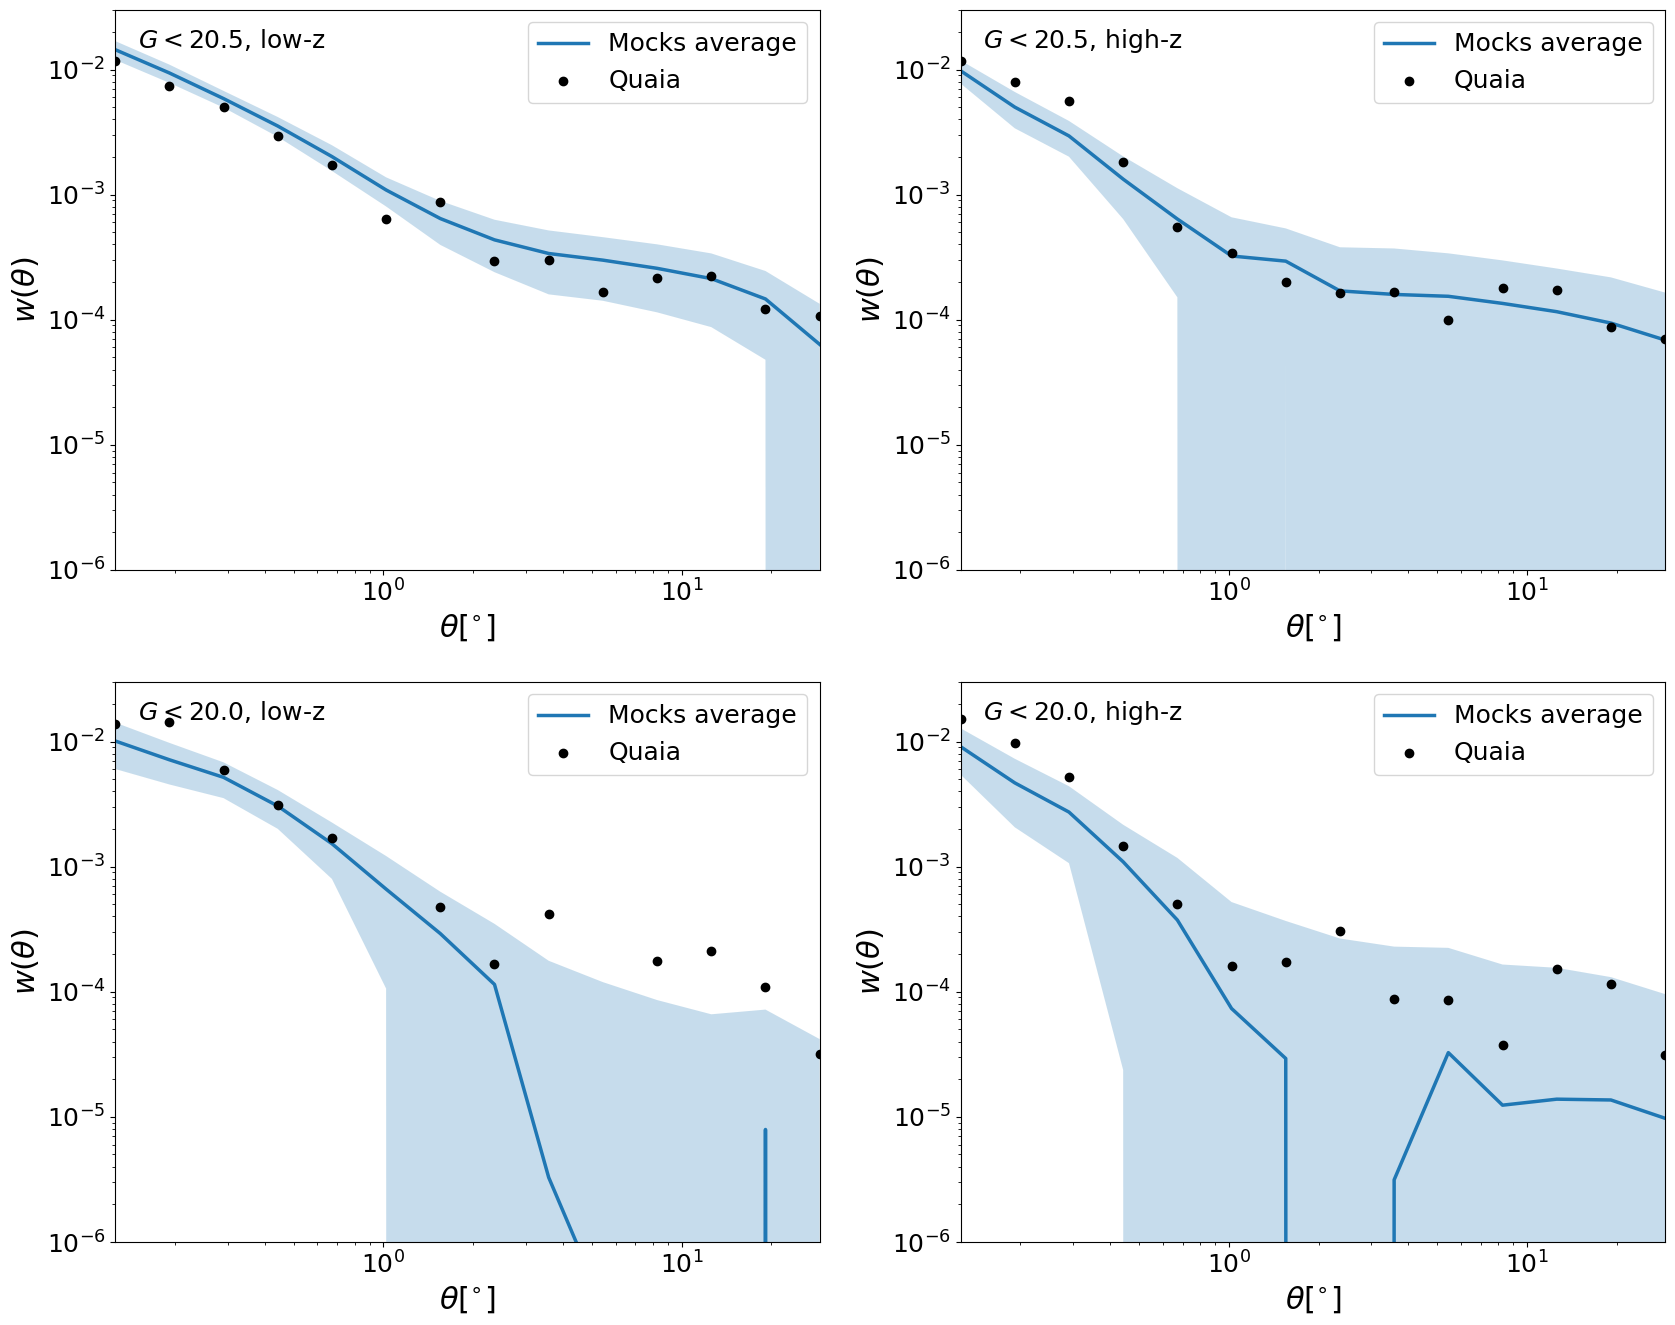

In [5]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2)

G_array = [20.5, 20]
j=0
for i in range(len(G_array)):
    for zbin, label in zip(z_array, ['low-z', 'high-z']):
        ax1 = fig.add_subplot(gs[j])
        mock = []
                
        for k in range(100):
            
            fname = '../results/wtheta_G{:.1f}_zsplit2bin{}_mock{}_25x.npy'.format(G_array[i], zbin, k+1)
            if os.path.isfile(fname):
                mock.append(np.load(fname))
                
        if len(mock)>=1:
            mock_mean = np.mean(mock, axis = 0)
            yerr = np.std(mock, axis = 0)
            ax1.plot(quaia.recenter(thetabins), mock_mean, linewidth = 2.5, label = 'Mocks average')
            ax1.fill_between(quaia.recenter(thetabins), y1 = mock_mean - yerr, y2 = mock_mean + yerr, alpha = 0.25)

        fname = '../results/wtheta_G{:.1f}_zsplit2bin{}_25x.npy'.format(G_array[i], zbin)
        if os.path.isfile(fname):
            ax1.scatter(quaia.recenter(thetabins), np.load(fname), color = 'black', label = 'Quaia', zorder = 3)

        ax1.set_xlabel(r'$\theta[^{\circ}]$')
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
        ax1.set_ylim(1e-6, 3e-2)
        ax1.set_ylabel(r"$w(\theta)$")
        ax1.text(0.15,1.5e-2,'$G<{:.1f}$, {}'.format(G_array[i], label), fontsize = 18)
        ax1.legend()
        j+=1

plt.show()

### Sanity check

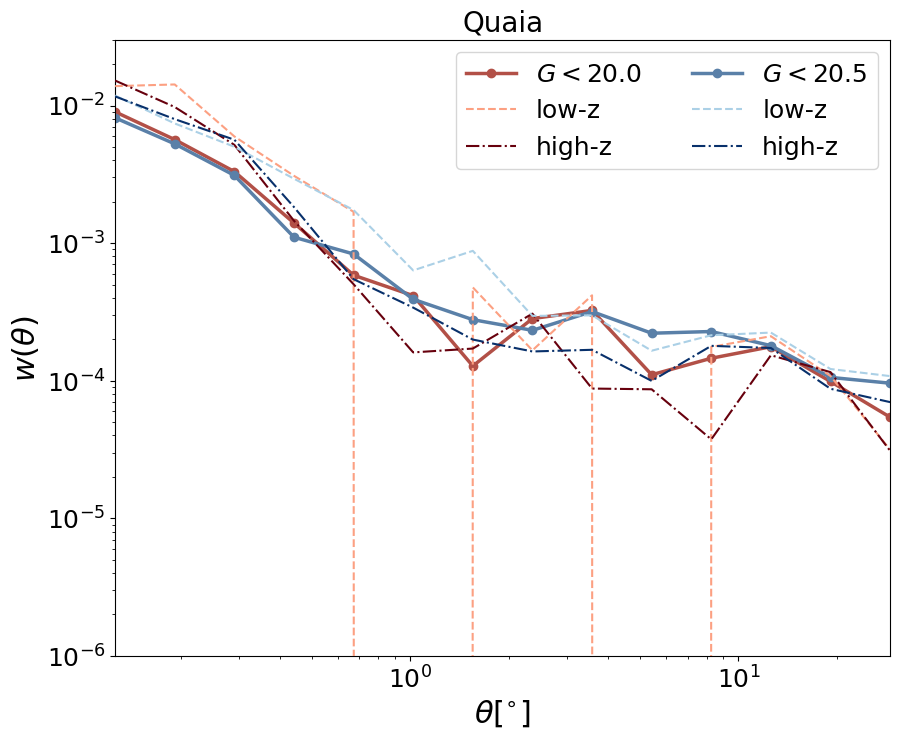

In [6]:
# plot!
fig = plt.figure(figsize = (10, 8))
gs = gridspec.GridSpec(1, 1, wspace = 0)

G_array = [20.0, 20.5]
i=0
ax1 = fig.add_subplot(gs[i])
for i in range(len(G_array)):
    wtheta = np.load('../results/wtheta_G{:.1f}.npy'.format(G_array[i]))
    ax1.plot(quaia.recenter(thetabins), wtheta, marker = 'o', label = '$G<{}$'.format(G_array[i]), linewidth = 2.5,
             color = np.mean(cmaps[i], axis = 0))
    
    for j, linestyle, label in zip([0,1], ['--', '-.'], ['low-z', 'high-z']):
        fname = '../results/wtheta_G{:.1f}_zsplit2bin{}_25x.npy'.format(G_array[i], j)
        if os.path.isfile(fname):
            ax1.plot(quaia.recenter(thetabins), np.load(fname), label = label, zorder = 3, 
                     color = cmaps[i][j], linestyle = linestyle)
ax1.set_title('Quaia')
ax1.set_xlabel(r'$\theta[^{\circ}]$') # projected
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlim(quaia.recenter(thetabins)[0], quaia.recenter(thetabins)[-1])
ax1.set_ylim(1e-6, 3e-2)
ax1.legend(ncol = 2)
ax1.set_ylabel(r"$w(\theta)$")

plt.show()

## $w_p(r_p)$

In [7]:
# Create the bins array
rmin = 0.15 # 0.5 # 0.1 # start higher
rmax = 240 # 120 #85 # 60.0 # 20.0 
nbins = 20 
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# rmin = 0.15 # 0.5 # 0.1 # start higher
# rmax = 210 # 120 #85 # 60.0 # 20.0 
# nbins = 20 
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

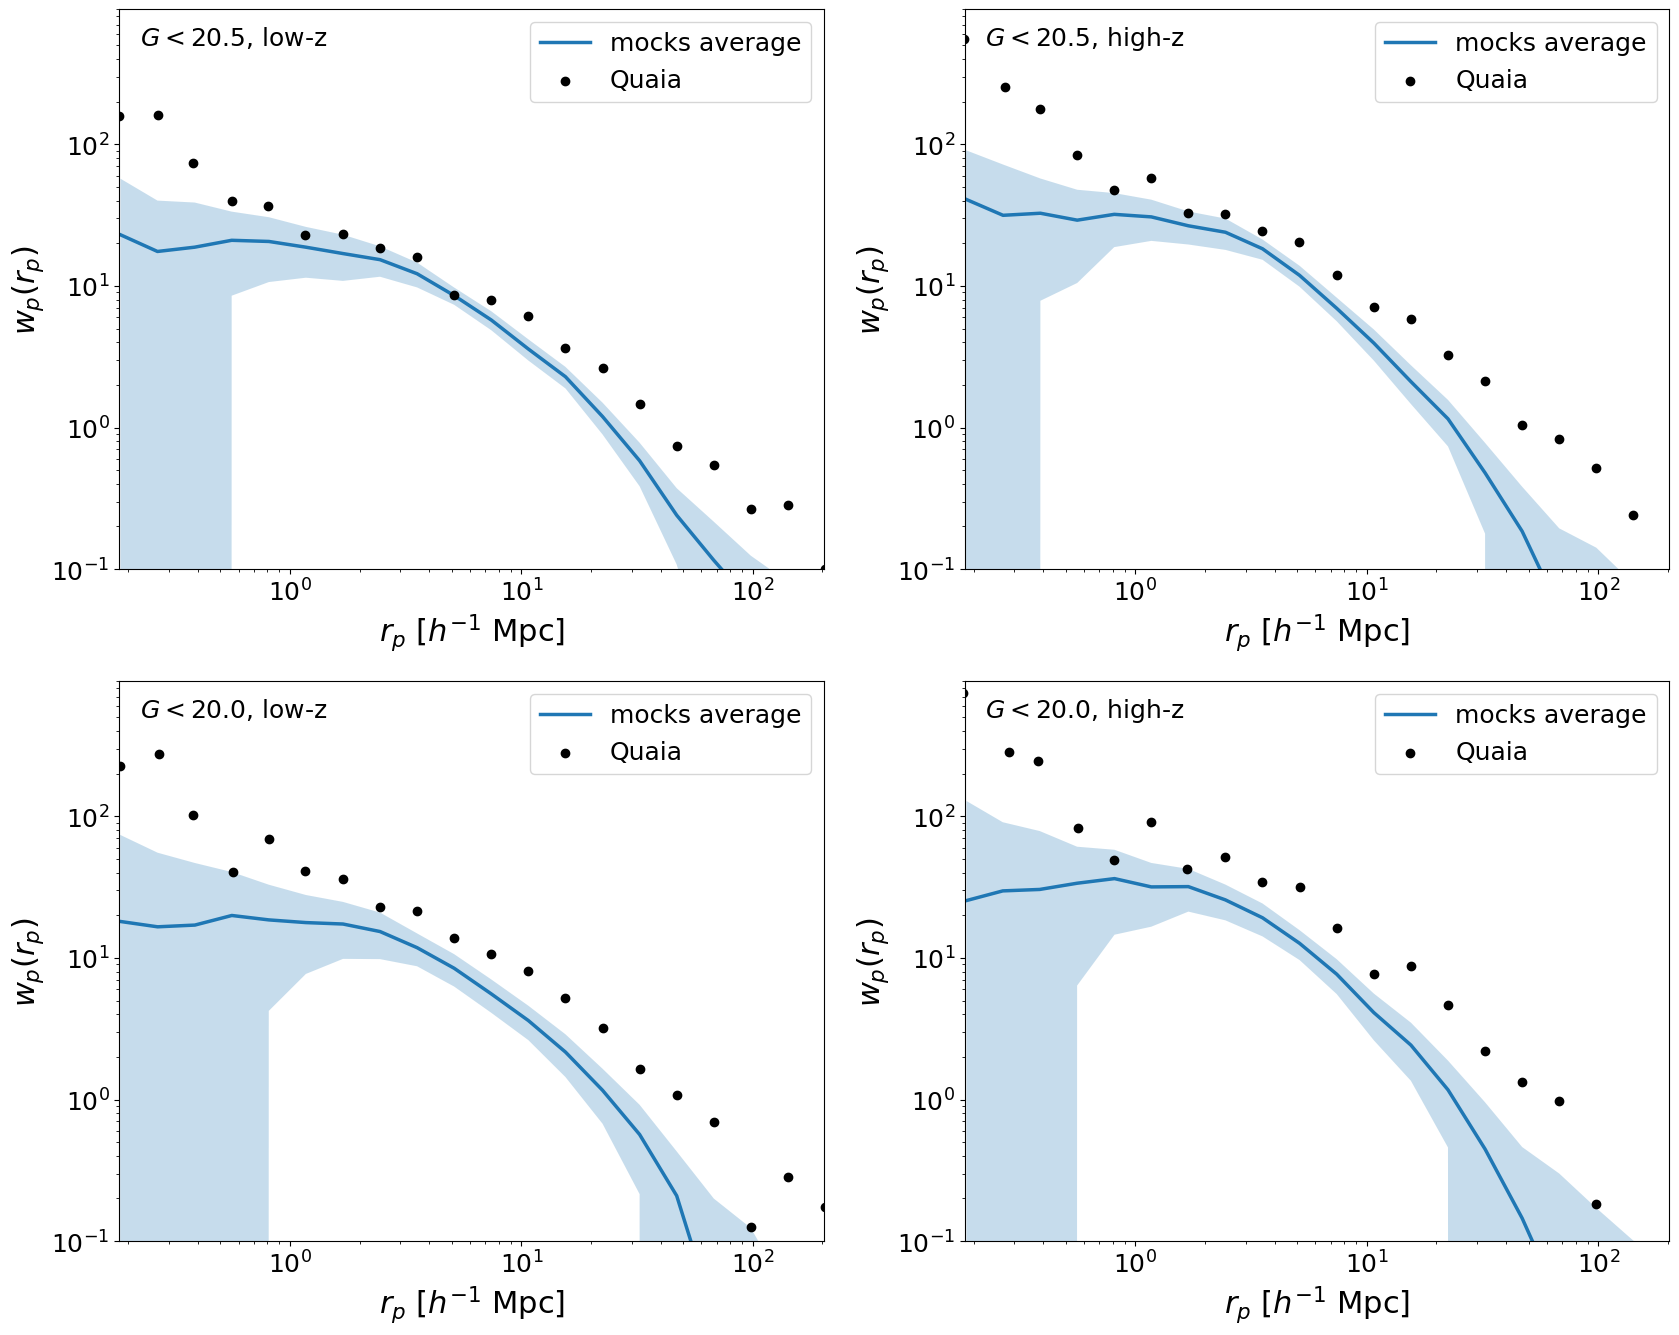

In [8]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2)
G_array = [20.5, 20]
j=0
for i in range(len(G_array)):
    for zbin, label in zip(z_array, ['low-z', 'high-z']):
        ax1 = fig.add_subplot(gs[j])
        mock_wp, mock_rpavg = [],[]
                
        for k in range(100):
            
            fname = '_G{:.1f}_zsplit2bin{}_mock{}_25x.npy'.format(G_array[i], zbin, k+1)
            if os.path.isfile('../results/wp{}'.format(fname)):
                # print(fname)
                mock_wp.append(np.load('../results/wp{}'.format(fname)))
                mock_rpavg.append(np.load('../results/rpavg{}'.format(fname)))
                
        if len(mock_wp)>=1:
            mock_wp_mean = np.mean(mock_wp, axis = 0)
            yerr = np.std(mock_wp, axis = 0)
            mock_rpavg_mean = np.mean(mock_rpavg, axis = 0)
            ax1.plot(mock_rpavg_mean, mock_wp_mean, linewidth = 2.5, label = 'mocks average')
            ax1.fill_between(mock_rpavg_mean, y1 = mock_wp_mean - yerr, y2 = mock_wp_mean + yerr, alpha = 0.25)
        
        fname = '_G{:.1f}_zsplit2bin{}_25x.npy'.format(G_array[i], zbin)
        if os.path.isfile('../results/wp{}'.format(fname)):
            ax1.scatter(np.load('../results/rpavg{}'.format(fname)), np.load('../results/wp{}'.format(fname)), color = 'black', label = 'Quaia', 
                        zorder = 3)

        ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]')
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(1e-1, 9e2)
        ax1.set_ylabel(r"$w_p(r_p)$")
        ax1.text(0.225,5e2,'$G<{:.1f}$, {}'.format(G_array[i], label), fontsize = 18)
        ax1.legend()
        j+=1

plt.show()

## $\xi(s)$

In [9]:
# Create the bins array
rmin = 0.1 # 0.1 # start higher
rmax = 180.0 # 20.0 #50.0
nbins = 20 #90 #20
rbins = np.logspace(np.log10(rmin), np.log10(rmax), nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
scale = 'log'

# # Create the bins array
# rmin = 0.1 # 0.1 # start higher
# rmax = 155.0 # 20.0 #50.0
# nbins = 20 #90 #20
# rbins = np.linspace(rmin, rmax, nbins + 1) # Mpc/h https://github.com/manodeep/Corrfunc/issues/202
# scale = 'lin'

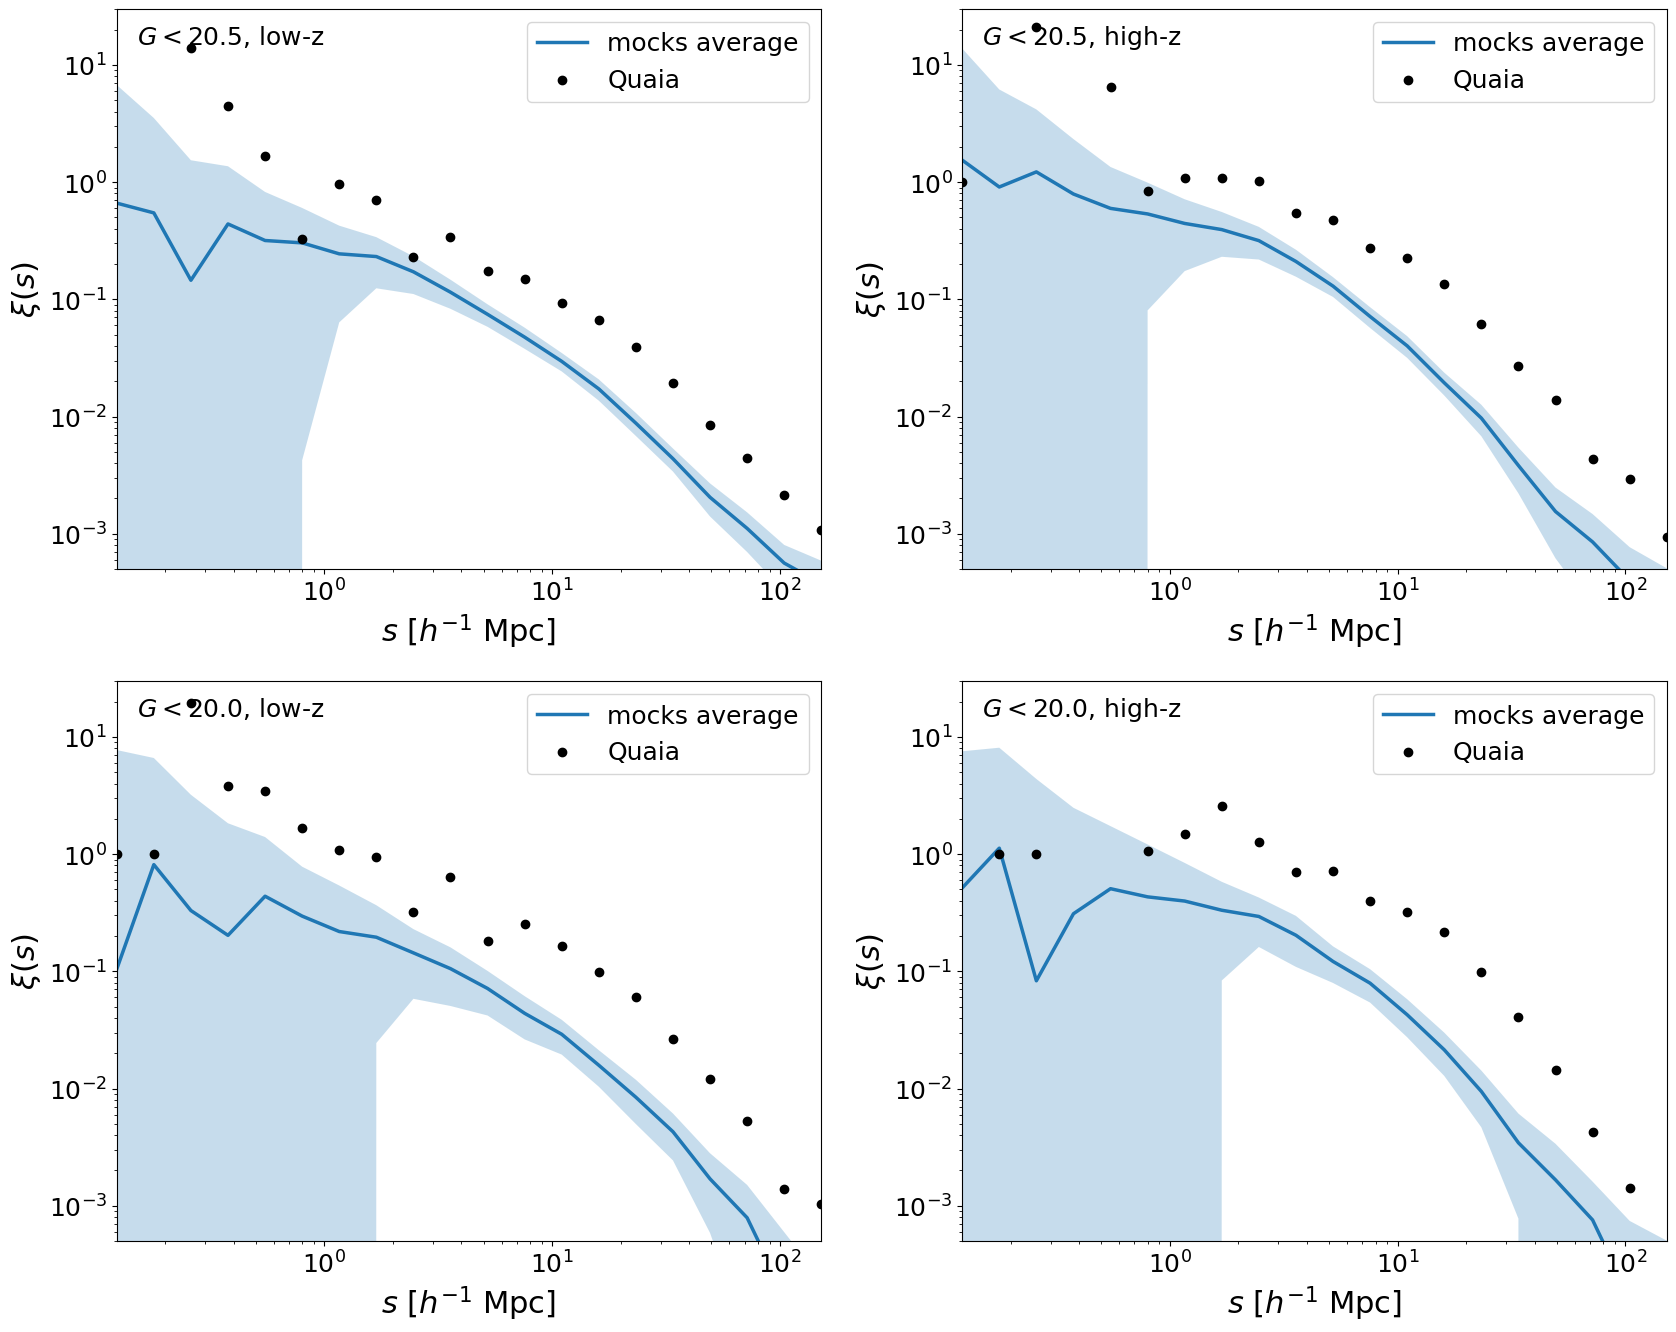

In [10]:
# plot!
fig = plt.figure(figsize = (20, 16))
gs = gridspec.GridSpec(2, 2)
G_array = [20.5, 20]
j=0
for i in range(len(G_array)):
    for zbin, label in zip(z_array, ['low-z', 'high-z']):
        ax1 = fig.add_subplot(gs[j])
        mock_wp = []
                
        for k in range(100):
            
            fname = '_G{:.1f}_zsplit2bin{}_mock{}_25x.npy'.format(G_array[i], zbin, k+1)
            if os.path.isfile('../results/xi{}'.format(fname)):
                # print(fname)
                mock_wp.append(np.load('../results/xi{}'.format(fname)))
                
        if len(mock_wp)>=1:
            mock_wp_mean = np.mean(mock_wp, axis = 0)
            yerr = np.std(mock_wp, axis = 0)
            ax1.plot(quaia.recenter(rbins), mock_wp_mean, linewidth = 2.5, label = 'mocks average')
            ax1.fill_between(quaia.recenter(rbins), y1 = mock_wp_mean - yerr, y2 = mock_wp_mean + yerr, alpha = 0.25)
        
        fname = '_G{:.1f}_zsplit2bin{}_25x.npy'.format(G_array[i], zbin)
        if os.path.isfile('../results/xi{}'.format(fname)):
            ax1.scatter(quaia.recenter(rbins), np.load('../results/xi{}'.format(fname)), color = 'black', label = 'Quaia', 
                        zorder = 3)

        ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]')
        ax1.set_xscale('log')
        ax1.set_yscale('log')
        ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
        ax1.set_ylim(5e-4, 3e1)
        ax1.set_ylabel(r"$\xi(s)$")
        ax1.text(0.15,1.5e1,'$G<{:.1f}$, {}'.format(G_array[i], label), fontsize = 18)
        ax1.legend()
        j+=1

plt.show()

### Try G20, facrand=10, galactic latitude mask b=20

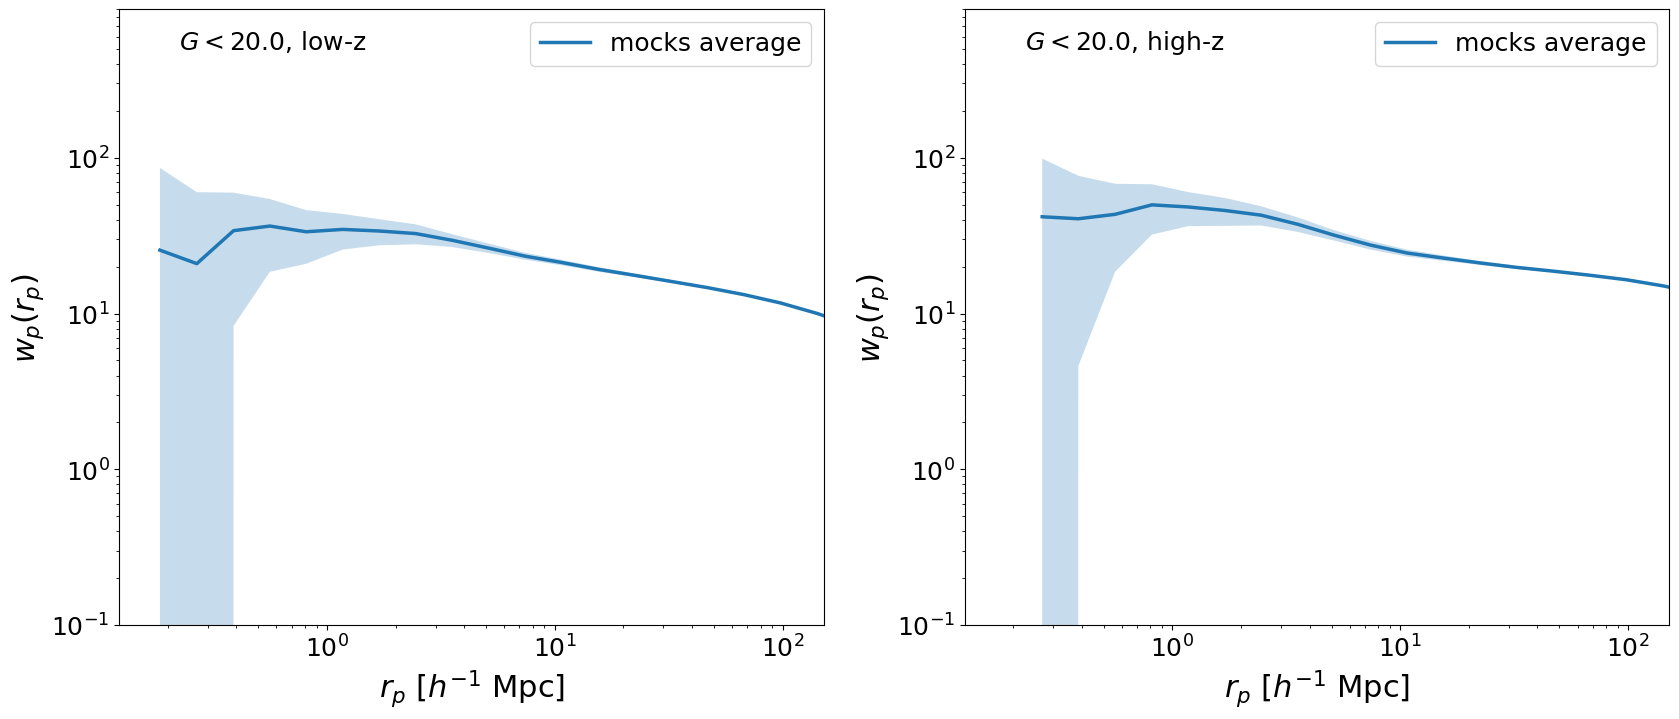

In [21]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2)
G_array = [20.5, 20]
j=0
G = 20
for zbin, label in zip(z_array, ['low-z', 'high-z']):
    ax1 = fig.add_subplot(gs[j])
    mock_wp, mock_rpavg = [],[]

    for k in range(100):

        fname = '_G{:.1f}_zsplit2bin{}_b20_mock{}_10x.npy'.format(G_array[i], zbin, k+1)
        if os.path.isfile('../results/wp{}'.format(fname)):
            # print(fname)
            mock_wp.append(np.load('../results/wp{}'.format(fname)))
            mock_rpavg.append(np.load('../results/rpavg{}'.format(fname)))

    if len(mock_wp)>=1:
        mock_wp_mean = np.mean(mock_wp, axis = 0)
        yerr = np.std(mock_wp, axis = 0)
        mock_rpavg_mean = np.mean(mock_rpavg, axis = 0)
        ax1.plot(mock_rpavg_mean, mock_wp_mean, linewidth = 2.5, label = 'mocks average')
        ax1.fill_between(mock_rpavg_mean, y1 = mock_wp_mean - yerr, y2 = mock_wp_mean + yerr, alpha = 0.25)

    fname = '_G{:.1f}_zsplit2bin{}_b20_10x.npy'.format(G_array[i], zbin)
    if os.path.isfile('../results/wp{}'.format(fname)):
        ax1.scatter(np.load('../results/rpavg{}'.format(fname)), np.load('../results/wp{}'.format(fname)), color = 'black', label = 'Quaia', 
                    zorder = 3)

    ax1.set_xlabel(r'$r_p$ $[h^{-1}$ Mpc]')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(1e-1, 9e2)
    ax1.set_ylabel(r"$w_p(r_p)$")
    ax1.text(0.225,5e2,'$G<{:.1f}$, {}'.format(G_array[i], label), fontsize = 18)
    ax1.legend()
    j+=1

plt.show()

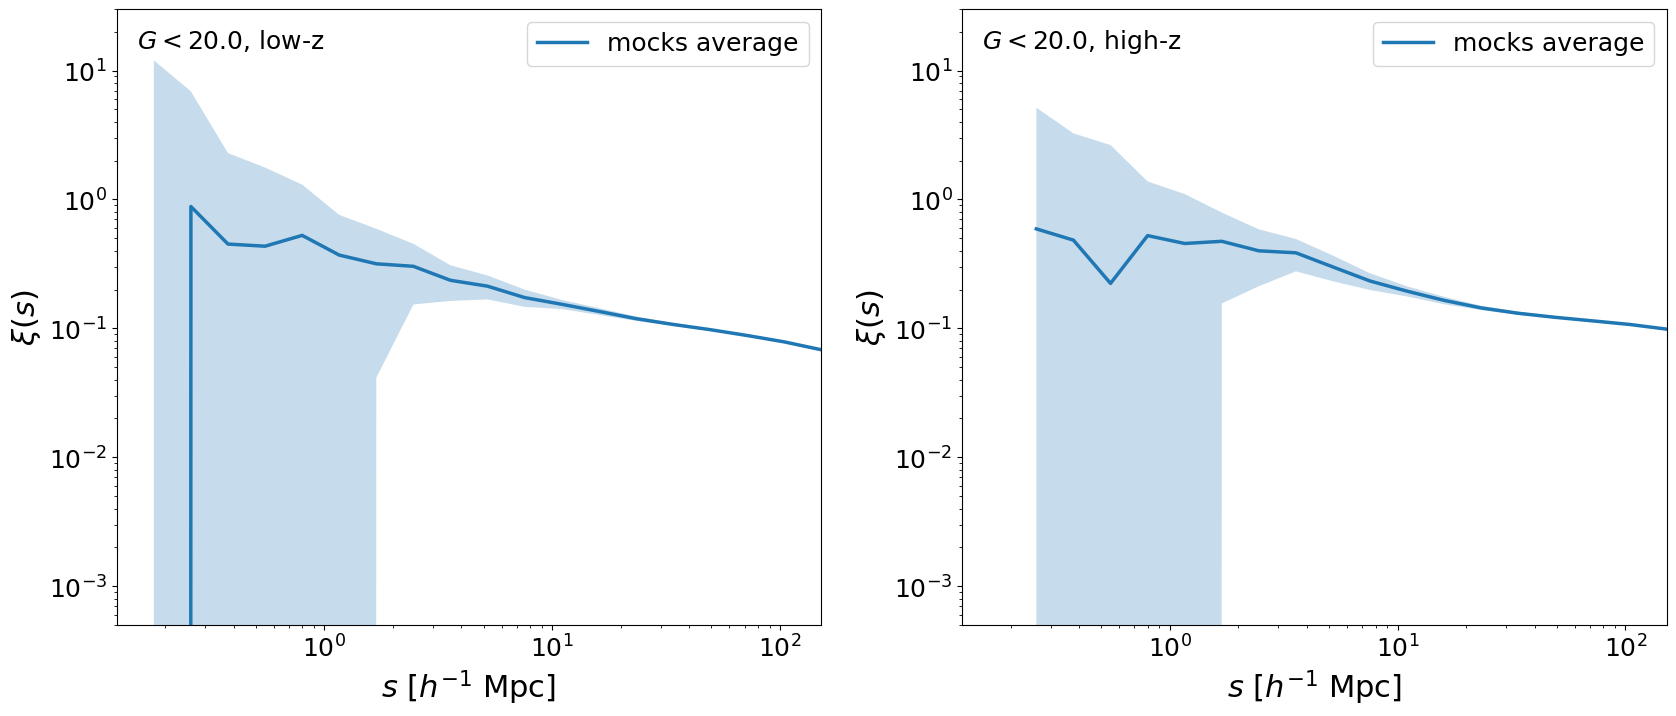

In [20]:
# plot!
fig = plt.figure(figsize = (20, 8))
gs = gridspec.GridSpec(1, 2)
# G_array = [20.5, 20]
j=0
G=20
# for i in range(len(G_array)):
for zbin, label in zip(z_array, ['low-z', 'high-z']):
    ax1 = fig.add_subplot(gs[j])
    mock_wp = []

    for k in range(100):

        fname = '_G{:.1f}_zsplit2bin{}_b20_mock{}_10x.npy'.format(G_array[i], zbin, k+1)
        if os.path.isfile('../results/xi{}'.format(fname)):
            # print(fname)
            mock_wp.append(np.load('../results/xi{}'.format(fname)))

    if len(mock_wp)>=1:
        mock_wp_mean = np.mean(mock_wp, axis = 0)
        yerr = np.std(mock_wp, axis = 0)
        ax1.plot(quaia.recenter(rbins), mock_wp_mean, linewidth = 2.5, label = 'mocks average')
        ax1.fill_between(quaia.recenter(rbins), y1 = mock_wp_mean - yerr, y2 = mock_wp_mean + yerr, alpha = 0.25)

    fname = '_G{:.1f}_zsplit2bin{}_b20_10x.npy'.format(G_array[i], zbin)
    if os.path.isfile('../results/xi{}'.format(fname)):
        ax1.scatter(quaia.recenter(rbins), np.load('../results/xi{}'.format(fname)), color = 'black', label = 'Quaia', 
                    zorder = 3)

    ax1.set_xlabel(r'$s$ $[h^{-1}$ Mpc]')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(quaia.recenter(rbins)[0], quaia.recenter(rbins)[-1])
    ax1.set_ylim(5e-4, 3e1)
    ax1.set_ylabel(r"$\xi(s)$")
    ax1.text(0.15,1.5e1,'$G<{:.1f}$, {}'.format(G_array[i], label), fontsize = 18)
    ax1.legend()
    j+=1

plt.show()